In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("titanic-dataset.csv")

In [3]:
data=pd.DataFrame(df)
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.columns
data.shape

(891, 12)

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#data.info()

In [7]:
data.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [8]:
data.shape

(891, 8)

In [9]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [10]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


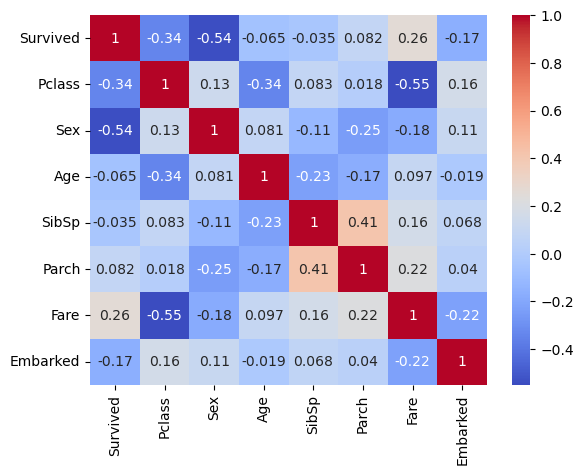

In [114]:
corr=data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [11]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
#le=LabelEncoder()
#data['Embarked']=le.fit_transform(data['Embarked'])

In [14]:
#data['Embarked'].value_counts()

In [15]:
data['Embarked'].fillna(data['Embarked'].mode()[0],inplace=True)

C:\Users\Abdullah Satti\AppData\Local\Temp\ipykernel_6356\1523684883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(data['Embarked'].mode()[0],inplace=True)


In [16]:
print(data['Embarked'].isnull().sum())

0


In [17]:
le=LabelEncoder()
data['Embarked']=le.fit_transform(data['Embarked'])

In [18]:
data['Embarked'].value_counts()

Embarked
2    646
0    168
1     77
Name: count, dtype: int64

In [25]:
#data['Age'].fillna(data['Age'].median(),inplace=True)

In [21]:
from sklearn.impute import SimpleImputer

In [23]:
imputer=SimpleImputer(strategy='median')
data['Age']=imputer.fit_transform(data[['Age']])

In [24]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [26]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [27]:
from sklearn.preprocessing import LabelEncoder

In [29]:
sex=LabelEncoder()
data['Sex']=sex.fit_transform(data['Sex'])

In [30]:
data['Sex'].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
x=data.drop('Survived',axis=1)
y=data['Survived']


In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [37]:
print("\nx train label",x_train.shape)


x train label (712, 7)


In [38]:
print("\nx test label",x_test.shape)


x test label (179, 7)


In [39]:
from sklearn.tree import DecisionTreeClassifier

In [91]:
#classifier=DecisionTreeClassifier(criterion='gini')
classifier=DecisionTreeClassifier(max_depth=3,criterion='entropy')
#classifier=DecisionTreeClassifier(max_depth=10,criterion='entropy')
#classifier=DecisionTreeClassifier(max_depth=1,criterion='entropy')

In [96]:
for depth in range(1,10):
    classifier=DecisionTreeClassifier(max_depth=3,criterion='entropy')
    

**training model**

In [97]:
classifier.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [98]:
pred=classifier.predict(x_test)
print("prediction")

prediction


In [99]:
training_score=classifier.score(x_train,y_train)*100
print("\ntraining score is ",training_score,"%")


training score is  82.58426966292134 %


In [95]:
testing_score=classifier.score(x_test,y_test)*100
print("\ntesting score is ",testing_score,"%")


testing score is  80.44692737430168 %


**Evaluation**

In [75]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score

In [76]:
cm=confusion_matrix(y_test,pred)
print("confusion matrix",cm)

confusion matrix [[99 11]
 [24 45]]


In [77]:
accuracy=accuracy_score(y_test,pred)*100
print("accuracy is",accuracy,"%")

accuracy is 80.44692737430168 %


In [78]:
f1=f1_score(y_test,pred)*100
print("f1 score is",f1,"%")

f1 score is 72.0 %


**visulize the decision tree**

In [79]:
from sklearn.tree import plot_tree

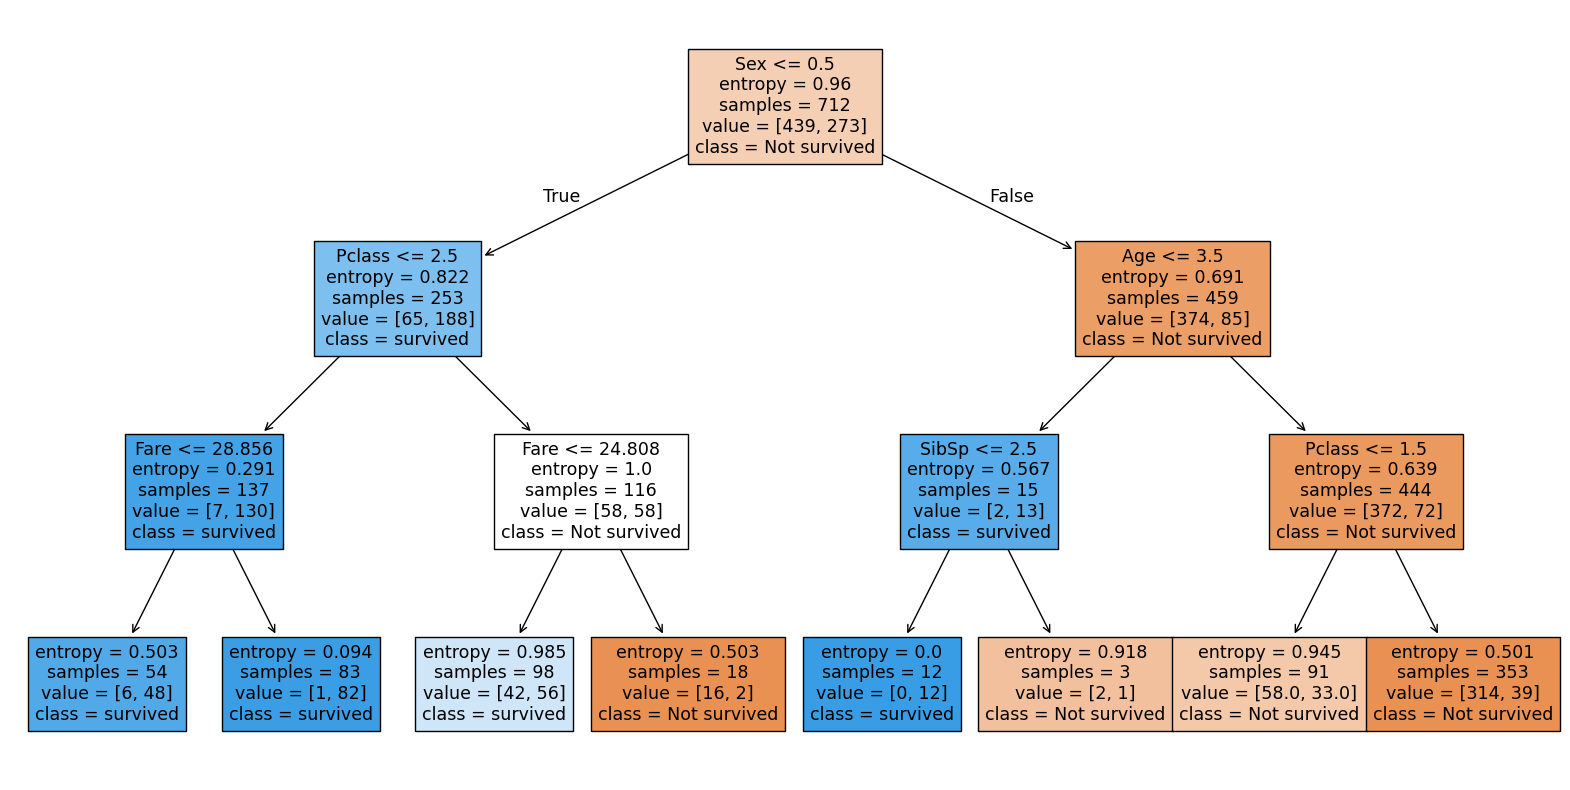

In [80]:
plt.figure(figsize=(20,10))
plot_tree(classifier,
         feature_names=x.columns,
         class_names=['Not survived','survived'],
         filled=True)
plt.show()

**checking feature importance**

In [102]:
feature_impot=pd.Series(classifier.feature_importances_,index=x.columns)*100
feature_impot

Pclass      26.328788
Sex         57.130003
Age          8.967439
SibSp        2.069395
Parch        0.000000
Fare         5.504375
Embarked     0.000000
dtype: float64

**visualize feature importance**

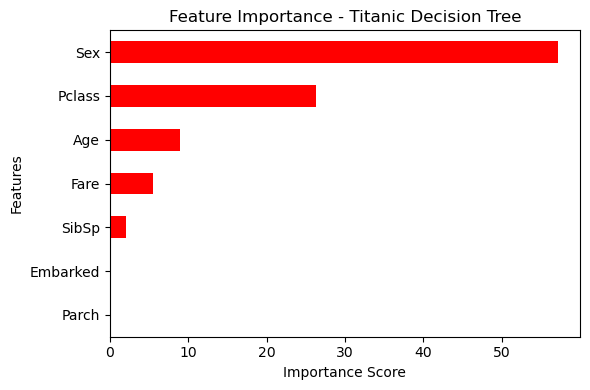

In [111]:
plt.figure(figsize=(6,4))
feature_impot.sort_values().plot(kind='barh',color='red')
plt.title('Feature Importance - Titanic Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()